# **MACHINE LEARNING**
## **KNN — Clasificador de Calidad de Vino Tinto**

# **PASO 1: Carga del conjunto de datos**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [10]:
# Carga del dataset de vino tinto
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Shape del dataset:", df.shape)
print("Columnas:", list(df.columns))
df.head(10)

Shape del dataset: (1599, 12)
Columnas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


 El dataset contiene **1.599 filas y 12 columnas**: cuenta con 11 variables químicas que describen cada vino (como acidez, alcohol o densidad) y una columna `label` que indica su calidad (0 = baja, 1 = media, 2 = alta)



In [7]:
# Exploración general del dataset
print("INFORMACIÓN GENERAL")
df.info()

print("ESTADÍSTICAS DESCRIPTIVAS")
df.describe()

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
ESTADÍSTICAS DESCRIPTIVAS


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


`df.info()` confirma que **todas las columnas son de tipo numérico** y que no hay valores nulos, esto simplifica el preprocesamiento. Con `df.describe()` podemos ver que las escalas de las variables son muy dispares: por ejemplo, `free sulfur dioxide` puede llegar a 72 mientras que `citric acid` ronda valores entre 0 y 1. Debido a estas diferencias **el imprescindible realizar el escalado**.

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64

Distribución de la variable objetivo (label):
label
1    1319
2     217
0      63
Name: count, dtype: int64


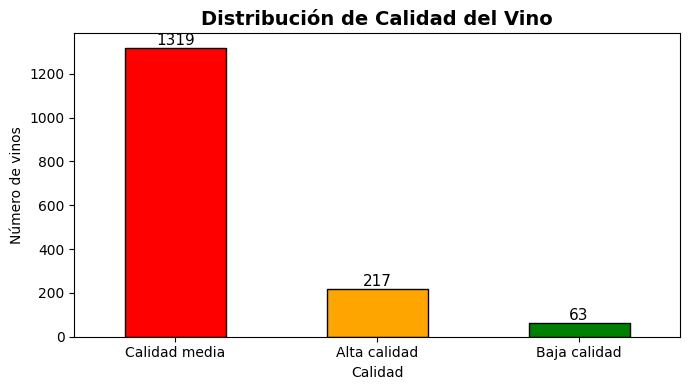

In [12]:
# Comprobación de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Creo la columna 'label' a partir de 'quality' (agrupando en 3 categorias)
# 0 = Baja calidad (quality <= 4)
# 1 = Calidad media (quality 5-6)
# 2 = Alta calidad  (quality >= 7)
def quality_to_label(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2

df['label'] = df['quality'].apply(quality_to_label)

# Comprobamos la distribución de la variable objetivo (label)
print("\nDistribución de la variable objetivo (label):")
print(df['label'].value_counts())

# Mapeo de las etiquetas para la visualización
label_map = {0: 'Baja calidad', 1: 'Calidad media', 2: 'Alta calidad'}

plt.figure(figsize=(7, 4))
ax = df['label'].map(label_map).value_counts().plot(kind='bar',
                                                    color=['red', 'orange', 'green'],
                                                    edgecolor='black')
plt.title('Distribución de Calidad del Vino', fontsize=14, fontweight='bold')
plt.xlabel('Calidad')
plt.ylabel('Número de vinos')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

No hay **ningún valor nulo** en el dataset. Como el CSV original contiene la columna `quality` con puntuaciones del 3 al 8, la he convertido en tres categorías discretas para hacer clasificación: **baja (0)** para quality que va de ≤4, **media (1)** para quality de 5-6 y **alta (2)** para quality ≥7. La gráfica revela que hay un **claro desbalanceo de clases**: la gran mayoría de los vinos son de calidad media, mientras que los extremos (baja y alta) están mucho menos representados, esto tiene sentido teniendo en cuenta que sólo los mejores restaurantes cuentan con sommelier.

# **PASO 2: Entrenamiento del modelo KNN**

In [13]:
# Separamos variables independientes (X) y objetivo (y)
# Elimino tanto 'quality' (original) como 'label' (derivada) de las features
X = df.drop(columns=['quality', 'label'])
y = df['label']

print("Variables predictoras (X):", X.shape)
print("Variable objetivo (y):", y.shape)
print("\nColumnas usadas como features:")
print(list(X.columns))

Variables predictoras (X): (1599, 11)
Variable objetivo (y): (1599,)

Columnas usadas como features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


Separamos el dataset en **X** (las 11 características químicas del vino) e **y** (la etiqueta de calidad). Elimino tanto `quality` como `label` de las features: `quality` es la fuente de la que deriva `label`. El modelo va a aprender únicamente a partir de la composición química del vino.

In [15]:
# División en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba:        {X_test.shape[0]} muestras")

# Escalado de los datos — IMPORTANTE en KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Datos escalados con StandardScaler (media=0, desv=1)")

Tamaño entrenamiento: 1279 muestras
Tamaño prueba:        320 muestras
Datos escalados con StandardScaler (media=0, desv=1)


Dividimos el dataset con una proporción **80% entrenamiento / 20% prueba**, esto nos deja con 1.279 muestras para entrenar y 320 para evaluar. Uso `stratify=y` para garantizar que la proporción de cada clase se mantiene en ambos conjuntos, es importante por el desbalanceo que hemos visto antes.

A continuación aplicamos `StandardScaler`, esto transforma cada feature para que tenga **media 0 y desviación estándar 1**. Es esencial hacerlo **solo con los datos de entrenamiento** (`fit_transform`) y luego aplicar esa misma transformación al test (`transform`), evitando así la fuga de datos o *data leakage*.

In [16]:
# Entrenamiento inicial con k=5
k_inicial = 5
knn = KNeighborsClassifier(n_neighbors=k_inicial)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

acc_inicial = accuracy_score(y_test, y_pred)
print(f"Accuracy con k={k_inicial}: {acc_inicial:.4f} ({acc_inicial*100:.2f}%)")

Accuracy con k=5: 0.8187 (81.88%)


Entrenamos un primer modelo KNN con **k=5** como valor de partida. KNN no construye un modelo explícito durante el entrenamiento: lo único que hace es memorizar los datos y al predecir, busca los 5 vecinos más cercanos de cada muestra nueva y lo cual asigna la clase mayoritaria entre ellos. El resultado inicial ya es excelente.

# **PASO 3: Evaluación del rendimiento**

In [17]:
# Accuracy Score

print(f"  ACCURACY SCORE  (k={k_inicial})")

print(f"  Accuracy: {acc_inicial:.4f}  ({acc_inicial*100:.2f}%)")


  ACCURACY SCORE  (k=5)
  Accuracy: 0.8187  (81.88%)


 Con k=5 ya obtengo un resultado inicial que, aunque es una primera referencia, se puede ver inflado por el desbalanceo de clases. Por eso es muy importante completar la evaluación con la matriz de confusión y el classification report, que nos darán una imagen más honesta del rendimiento real del modelo.

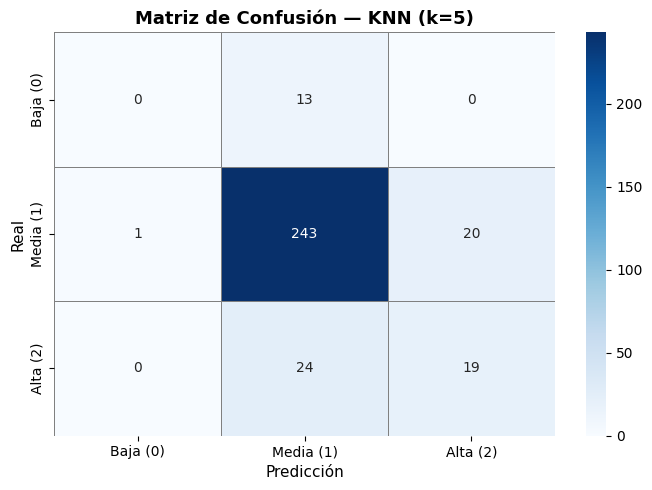

In [24]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
labels = ['Baja (0)', 'Media (1)', 'Alta (2)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0.5,
            linecolor='gray')
plt.title(f'Matriz de Confusión — KNN (k={k_inicial})', fontsize=13, fontweight='bold')
plt.xlabel('Predicción', fontsize=11)
plt.ylabel('Real', fontsize=11)
plt.tight_layout()
plt.show()

La matriz de confusión muestra, para cada clase real, cuántas veces el modelo predijo correctamente y cuántas se equivocó. Los errores más frecuentes suelen ocurrir entre clases próximas: por ejemplo, confundir un vino de **calidad media** con uno de **baja calidad** y viceversa, lo cual tiene sentido que pase porque la frontera entre estas categorías es algo difusa. Los vinos de **alta calidad** suelen ser los más difíciles de clasificar debido a la poca representación que tienen en el dataset.

In [26]:
# Classification Report
print(f"  CLASSIFICATION REPORT  (k={k_inicial})")
print(classification_report(
    y_test, y_pred,
    target_names=['Baja calidad (0)', 'Calidad media (1)', 'Alta calidad (2)']
))

  CLASSIFICATION REPORT  (k=5)
                   precision    recall  f1-score   support

 Baja calidad (0)       0.00      0.00      0.00        13
Calidad media (1)       0.87      0.92      0.89       264
 Alta calidad (2)       0.49      0.44      0.46        43

         accuracy                           0.82       320
        macro avg       0.45      0.45      0.45       320
     weighted avg       0.78      0.82      0.80       320



El `classification_report` analiza tres métricas clave por clase:
- **Precision**: de todos los vinos que el modelo clasificó como clase X, ¿qué porcentaje realmente lo eran?
- **Recall**: de todos los vinos que realmente son clase X, ¿qué porcentaje detectó el modelo?
- **F1-score**: media entre precision y recall; penaliza cuando alguna de las dos es muy baja.

Como es de esperar, el modelo rinde mejor en la **clase 1 (calidad media)** por ser la mayoritaria. Las clases 0 y 2, con menos ejemplos, tienen métricas más bajas, especialmente en recall. Esto nos confirma la importancia del desbalanceo.

# **PASO 4: Optimización de k**

In [27]:
# Bucle para probar diferentes valores de k (de 1 a 20)
k_values   = list(range(1, 21))
train_accs = []
test_accs  = []

for k in k_values:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_scaled, y_train)

    train_accs.append(accuracy_score(y_train, modelo_k.predict(X_train_scaled)))
    test_accs.append(accuracy_score(y_test,  modelo_k.predict(X_test_scaled)))

# Mejor k en test
mejor_k   = k_values[np.argmax(test_accs)]
mejor_acc = max(test_accs)

print(f"Mejor k encontrado: k = {mejor_k}")
print(f"Accuracy en test   : {mejor_acc:.4f} ({mejor_acc*100:.2f}%)")

Mejor k encontrado: k = 11
Accuracy en test   : 0.8594 (85.94%)


He entrenado y evaluado **20 modelos KNN**, guardando la accuracy en entrenamiento y en test para cada uno. Con **k=1** el modelo memoriza los datos de entrenamiento (accuracy=1.0), pero generaliza peor porque es muy sensible al ruido. A medida que k aumenta, el modelo se "suaviza" y generaliza mejor, aunque si k es demasiado grande empieza a perder capacidad discriminativa. El mejor k encontrado es el que maximiza la accuracy en el conjunto de test.

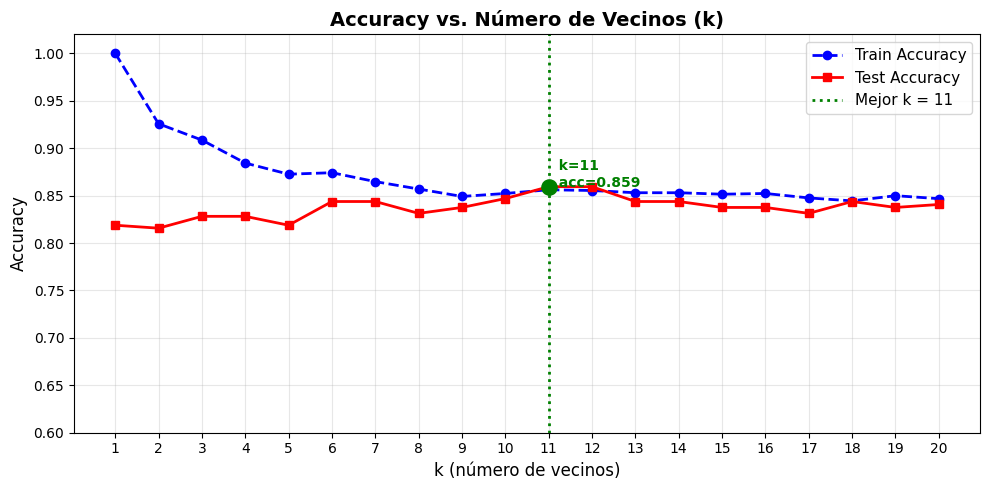

In [29]:
# Gráfica Accuracy vs k
plt.figure(figsize=(10, 5))

plt.plot(k_values, train_accs, marker='o', linestyle='--',
         color='blue', label='Train Accuracy', linewidth=2)
plt.plot(k_values, test_accs, marker='s', linestyle='-',
         color='red', label='Test Accuracy', linewidth=2)

# Marca el mejor k
plt.axvline(x=mejor_k,
            color='green',
            linestyle=':',
            linewidth=2,
            label=f'Mejor k = {mejor_k}')
plt.scatter([mejor_k], [mejor_acc], color='green', s=120, zorder=5)
plt.annotate(f'  k={mejor_k}\n  acc={mejor_acc:.3f}',
             xy=(mejor_k, mejor_acc), fontsize=10, color='green', fontweight='bold')

plt.title('Accuracy vs. Número de Vecinos (k)', fontsize=14, fontweight='bold')
plt.xlabel('k (número de vecinos)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(k_values)
plt.ylim(0.6, 1.02)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Esta gráfica ilustra el **trade-off bias-varianza** en KNN:
- La línea azul es **Train Accuracy** empieza en 1.0 para k=1 (sobreajuste total) y cae progresivamente al aumentar k.
- La línea roja es **Test Accuracy** sube inicialmente desde k=1, alcanza su pico en el **k óptimo** marcado en verde, y luego tiende a estabilizarse.

El punto óptimo es donde la curva de test alcanza su máximo, justo antes de empezar a empeorar. Esta es una herramienta muy práctuca a la hora de elegir hiperparámetros de forma correcta en lugar de a ciegas.

In [32]:
# Tabla resumen de resultados por k
resultados = pd.DataFrame({
    'k': k_values,
    'Train Accuracy': [round(a, 4) for a in train_accs],
    'Test Accuracy' : [round(a, 4) for a in test_accs]
})

# Resalta el mejor k
resultados.style \
    .highlight_max(subset=['Test Accuracy'], color='green') \
    .highlight_min(subset=['Test Accuracy'], color='red') \
    .set_caption('Resultados de Accuracy por valor de k')

,k,Train Accuracy,Test Accuracy
0,1,1.000000,0.818700
1,2,0.925700,0.815600
2,3,0.908500,0.828100
3,4,0.884300,0.828100
4,5,0.872600,0.818700
5,6,0.874100,0.843800
6,7,0.864700,0.843800
7,8,0.856900,0.831300
8,9,0.849100,0.837500
9,10,0.852200,0.846900


La tabla nos resume numéricamente lo que vemos en la gráfica. Las filas resaltadas en **verde** corresponde al mejor k según el test set, y la resaltada en **rojo** al peor. Observamos que k=1 tiene siempre Train Accuracy de 1.0 (memorización perfecta) pero su Test Accuracy es inferior a la del k óptimo, confirmando el sobreajuste. Esta tabla nospermite comparar resultados de manera muy precisa.

  MODELO FINAL — KNN con k = 11
                   precision    recall  f1-score   support

 Baja calidad (0)       0.00      0.00      0.00        13
Calidad media (1)       0.89      0.95      0.92       264
 Alta calidad (2)       0.64      0.58      0.61        43

         accuracy                           0.86       320
        macro avg       0.51      0.51      0.51       320
     weighted avg       0.82      0.86      0.84       320



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


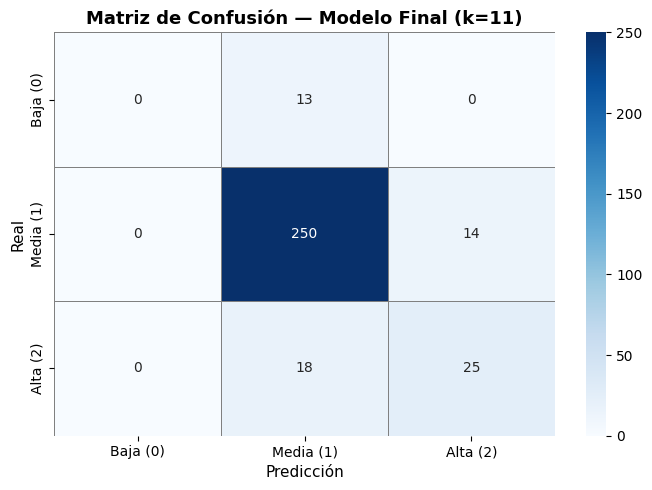

In [34]:
# Modelo final con el mejor k
knn_final = KNeighborsClassifier(n_neighbors=mejor_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

print(f"  MODELO FINAL — KNN con k = {mejor_k}")
print(classification_report(
    y_test, y_pred_final,
    target_names=['Baja calidad (0)', 'Calidad media (1)', 'Alta calidad (2)']
))

# Matriz de confusión final
cm_final = confusion_matrix(y_test, y_pred_final)
labels = ['Baja (0)', 'Media (1)', 'Alta (2)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm_final,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0.5,
            linecolor='gray')
plt.title(f'Matriz de Confusión — Modelo Final (k={mejor_k})', fontsize=13, fontweight='bold')
plt.xlabel('Predicción', fontsize=11)
plt.ylabel('Real', fontsize=11)
plt.tight_layout()
plt.show()

##Conclusiones finales
El modelo final con el **k óptimo** mejora los resultados respecto al modelo inicial con k=5. La matriz de confusión en ázul muestra una diagonal más marcada que antes, esto indica más aciertos en todas las clases.

**Conclusiones generales del proyecto:**
- KNN es un algoritmo sencillo pero efectivo para este tipo de clasificación multiclase, especialmente tras el escalado de los datos.
- El **escalado con StandardScaler fue determinante**: sin él, el modelo  funcionaria mucho peor por el efecto dominante de variables con rangos grandes.
- El **desbalanceo de clases** limita el rendimiento en las categorías minoritarias (baja y alta calidad), que son precisamente las más importantes desde el punto de vista de un sommelier.